In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import (
    brunnermunzel,
    gaussian_kde
)

from pathlib import Path

In [2]:
OUTPUT_DIR = Path(
    "partnership_analysis_outputs"
)

OUTPUT_DIR.mkdir(
    exist_ok=True
)

OUTPUT_DIR

WindowsPath('partnership_analysis_outputs')

In [3]:
file_path=r"C:\Users\Seun.Ale\OneDrive - Technological University Dublin\Desktop\Fixed vs Dynamic Partnership\..Latest M4.tmp new partnership sensitivity-table.xlsx"

df=pd.read_excel(
    file_path
)

df.columns=(
    df.columns
    .astype(str)
    .str.strip()
)

print(df.columns.tolist())

['[run number]', 'sharers-only-size', 'core-link', 'initial-infected', 'num-core', 'inner-link', 'outer-link', 'sharing-rate-sensitivity-level', 'num-inner', 'full-population-size', 'num-links', 'debug-mode?', 'full-population?', 'proximity-risk?', 'inner-interactions-per-day', 'total-interactions-per-day', 'num-outer', 'core-interactions-per-day', '[step]', 'Unnamed: 19', 'chronic_Y1', 'chronic_Y2', 'chronic_Y3', 'chronic_Y4', 'chronic_Y5', 'chronic_Y6', 'Unnamed: 26', 'Cured_Y1', 'Cured_Y2', 'Cured_Y3', 'Cured_Y4', 'Cured_Y5', 'Cured_Y6', 'Unnamed: 33', 'Treat_Y1', 'Treat_Y2', 'Treat_Y3', 'Treat_Y4', 'Treat_Y5', 'Treat_Y6', 'Unnamed: 40', 'Inc_Y1', 'Inc_Y2', 'Inc_Y3', 'Inc_Y4', 'Inc_Y5', 'Inc_Y6', 'Unnamed: 47', 'Ever_Treat_Y1', 'Ever_Treat_Y2', 'Ever_Treat_Y3', 'Ever_Treat_Y4', 'Ever_Treat_Y5', 'Ever_Treat_Y6']


In [4]:
group_col="proximity-risk?"
sharing_col="sharing-rate-sensitivity-level"

df[group_col]=pd.to_numeric(
    df[group_col],
    errors="coerce"
)

df=df.dropna(
    subset=[group_col]
)

baseline=df[
    df[sharing_col]=="baseline"
]

dynamic=baseline[
    baseline[group_col]==1
]

fixed=baseline[
    baseline[group_col]==0
]

print(
len(dynamic),
len(fixed)
)

100 100


In [5]:
OUTCOMES={

"Incidence":
"Inc_Y5",

"Prevalence":
"chronic_Y5",

"Cumulative Treatment":
"Ever_Treat_Y5",

"Cures":
"Cured_Y5"

}

In [6]:
def superiority(
    fixed_vals,
    dynamic_vals
):

    greater=0
    equal=0

    for x in fixed_vals:

        for y in dynamic_vals:

            if x>y:

                greater+=1

            elif x==y:

                equal+=1

    return (
        greater+
        0.5*equal
    )/(
        len(fixed_vals)*
        len(dynamic_vals)
    )


def iqr(x):

    return (
        np.percentile(
            x,
            75
        )
        -
        np.percentile(
            x,
            25
        )
    )

In [7]:
def distribution_plot(
    dynamic_vals,
    fixed_vals,
    outcome_name
):

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde

    plt.rcParams.update({

        "font.size":20,
        "axes.labelsize":20,
        "axes.titlesize":24,
        "xtick.labelsize":18,
        "ytick.labelsize":18,
        "legend.fontsize":18,
        "axes.linewidth":2.0

    })

    fig,axes=plt.subplots(

        1,
        2,
        figsize=(14,6),
        dpi=600,
        constrained_layout=True

    )

    datasets=[

        (dynamic_vals,"Dynamic"),
        (fixed_vals,"Fixed")

    ]

    for ax,(vals,title) in zip(
        axes,
        datasets
    ):

        vals=np.asarray(vals)

        median=np.median(vals)

        q1=np.percentile(vals,25)

        q3=np.percentile(vals,75)

        # Histogram

        ax.hist(

            vals,
            bins=25,
            density=True,
            alpha=.25,
            edgecolor="none"

        )

        # KDE

        if len(np.unique(vals))>1:

            x=np.linspace(

                vals.min(),
                vals.max(),
                600

            )

            kde=gaussian_kde(vals)

            ax.plot(

                x,
                kde(x),
                linewidth=3

            )

        # Median line

        ax.axvline(

            median,
            linestyle="--",
            linewidth=2

        )

        # Median + IQR annotation

        annotation=(

            f"Median={median:.1f}\n"
            f"IQR [{q3-q1:.2f}]"

        )

        ax.text(

            .97,
            .95,
            annotation,

            transform=ax.transAxes,

            ha="right",
            va="top",

            bbox=dict(

                boxstyle="round",
                facecolor="none",
                edgecolor="black",
                linewidth=1


            ),

            fontsize=16

        )

        ax.set_title(title)

        ax.spines["top"].set_visible(False)

        ax.spines["right"].set_visible(False)

        ax.set_ylabel(
            "Density"
        )

    fig.supxlabel(

        outcome_name,
        fontsize=16

    )

    plt.savefig(

        OUTPUT_DIR/
        f"{outcome_name}.png",

        dpi=600,

        bbox_inches="tight"

    )

    plt.savefig(

        OUTPUT_DIR/
        f"{outcome_name}.pdf",

        bbox_inches="tight"

    )

    plt.show()

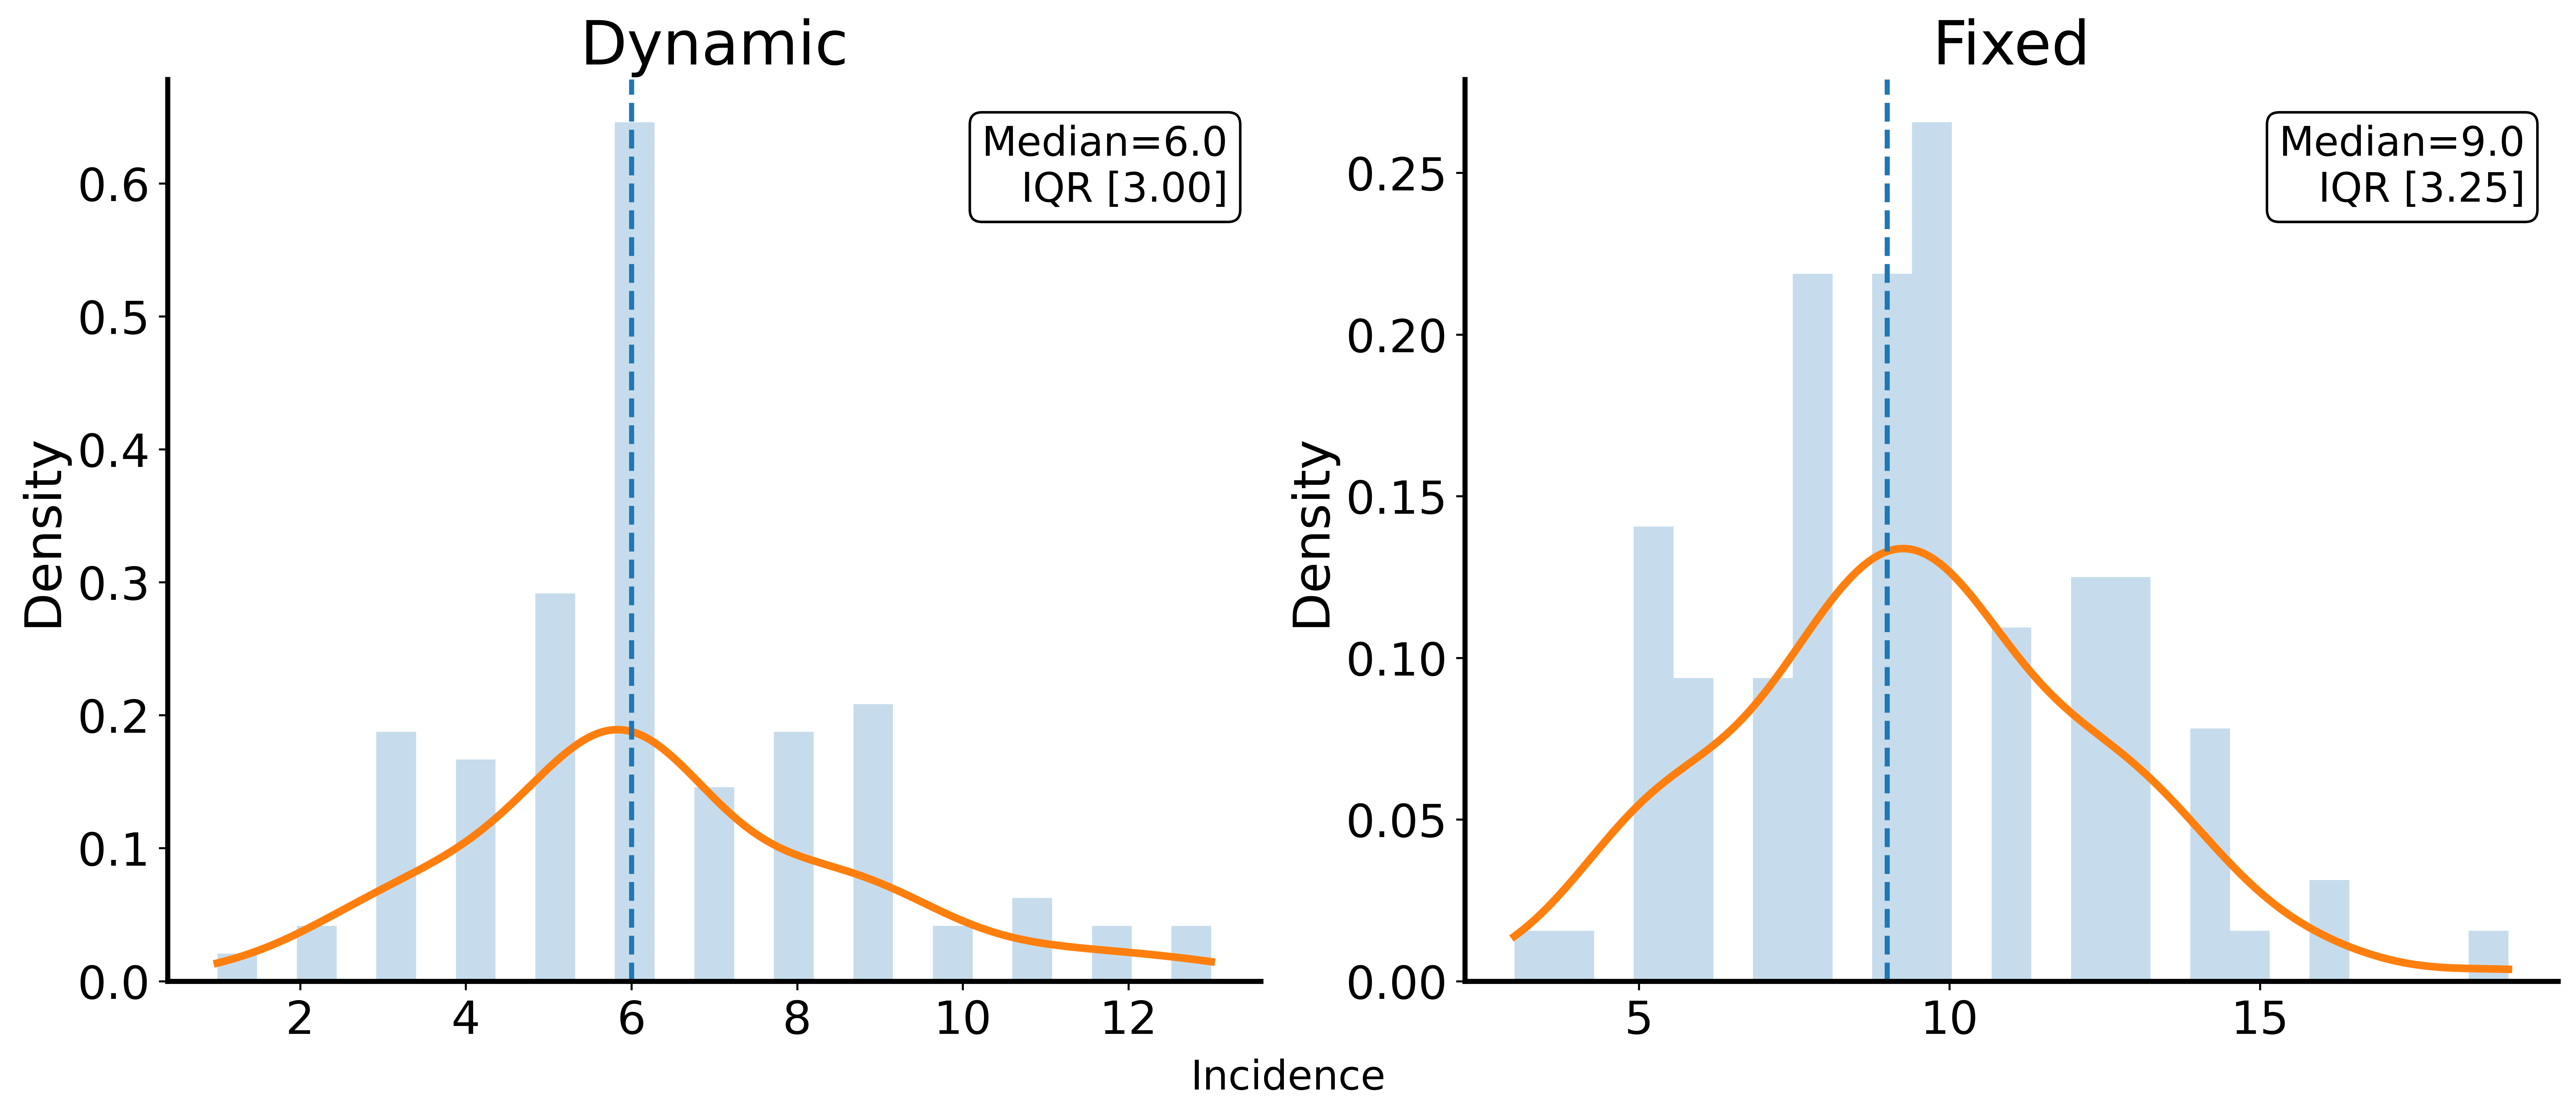

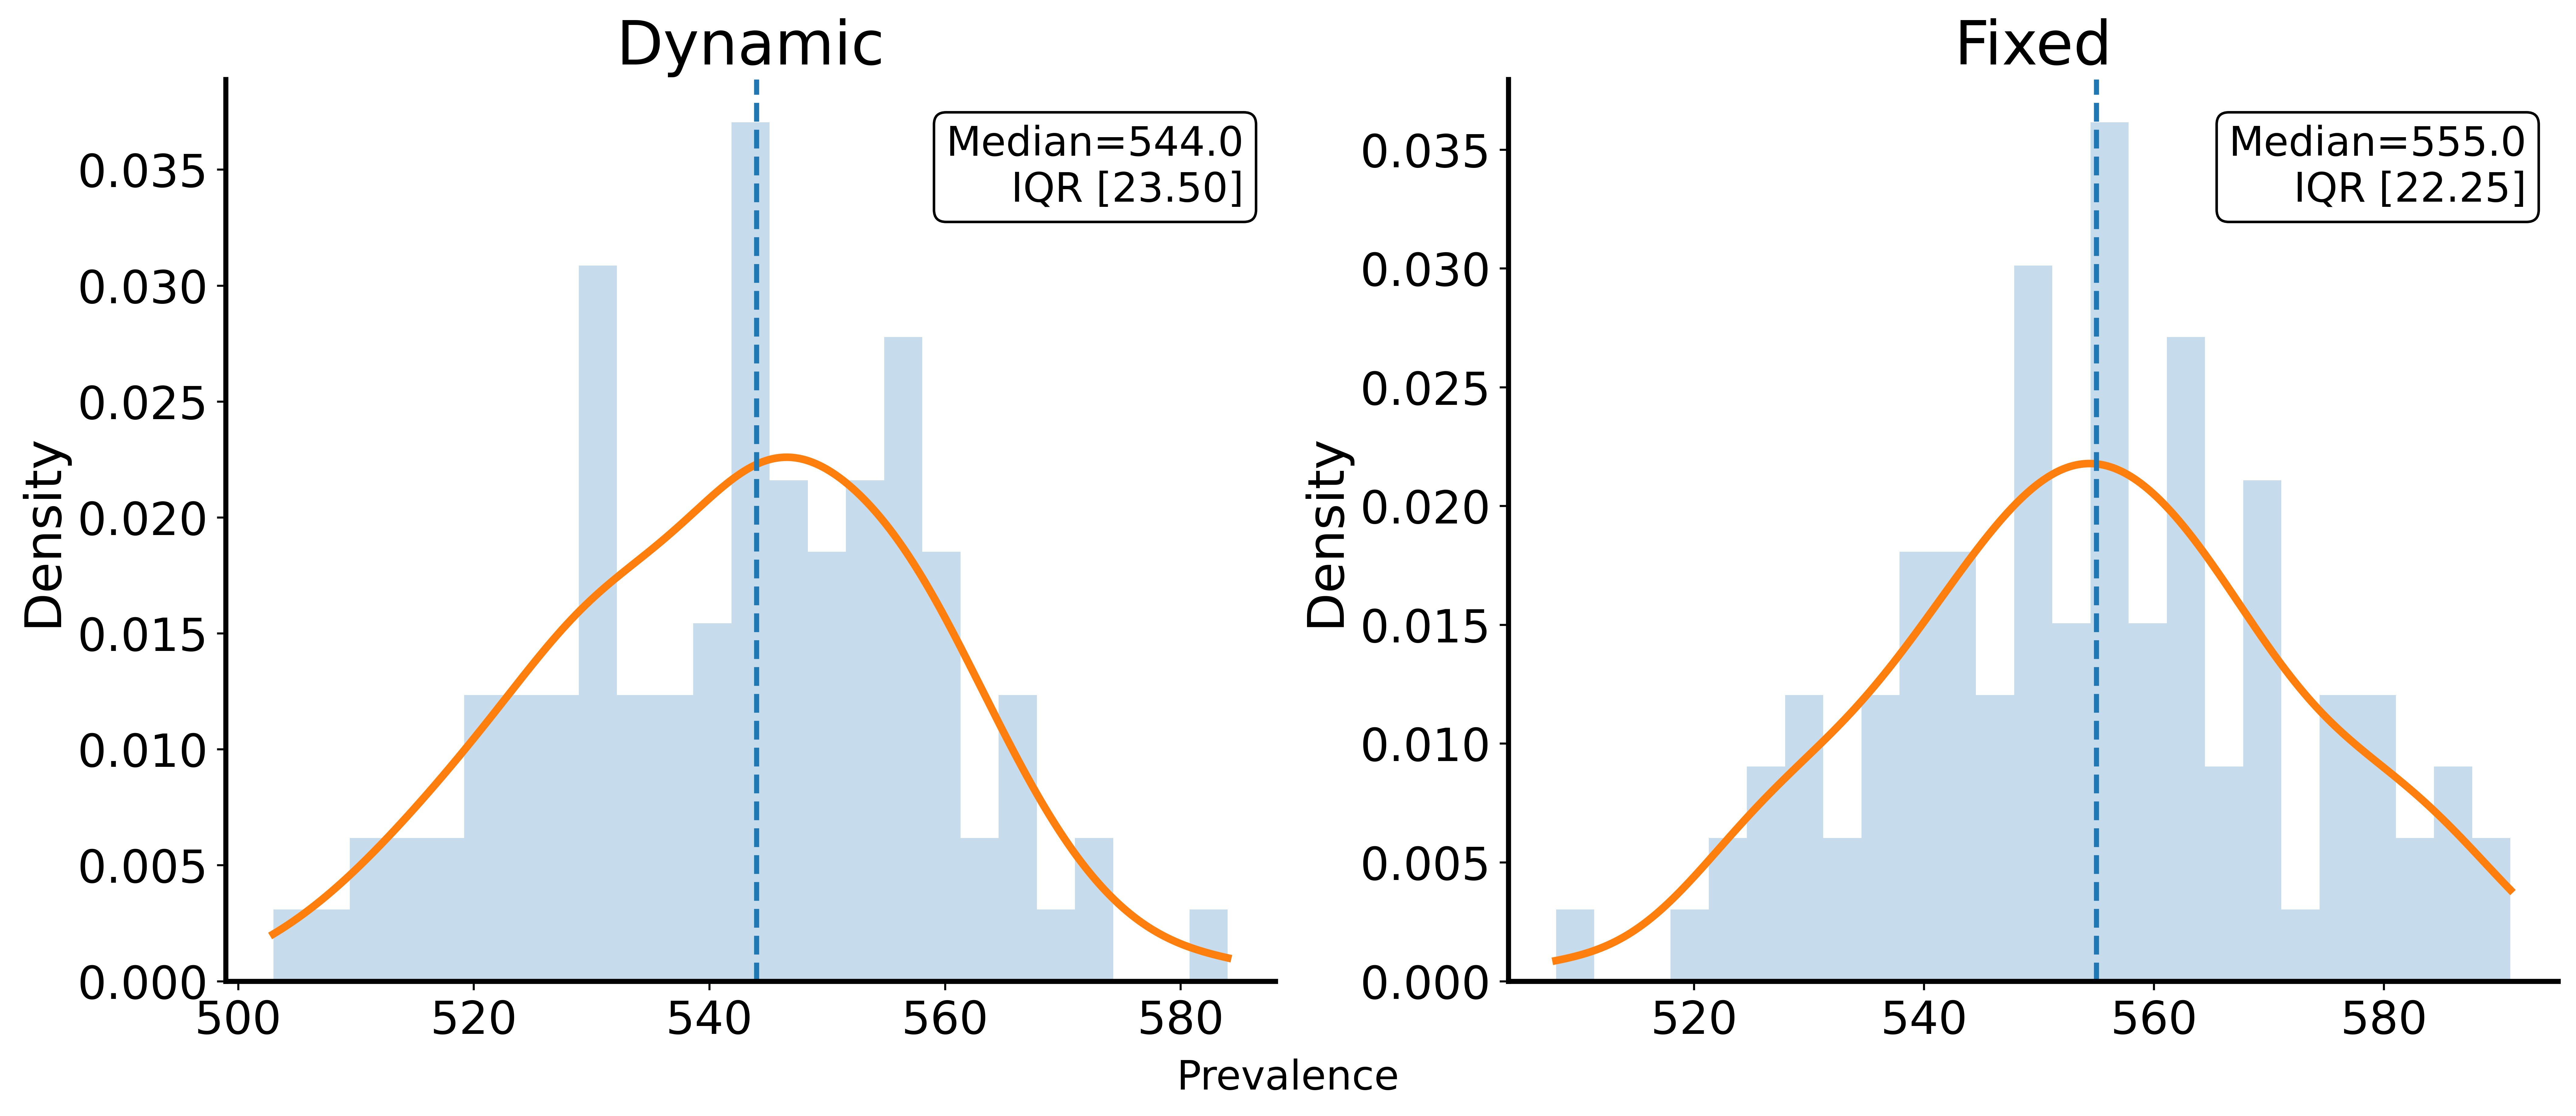

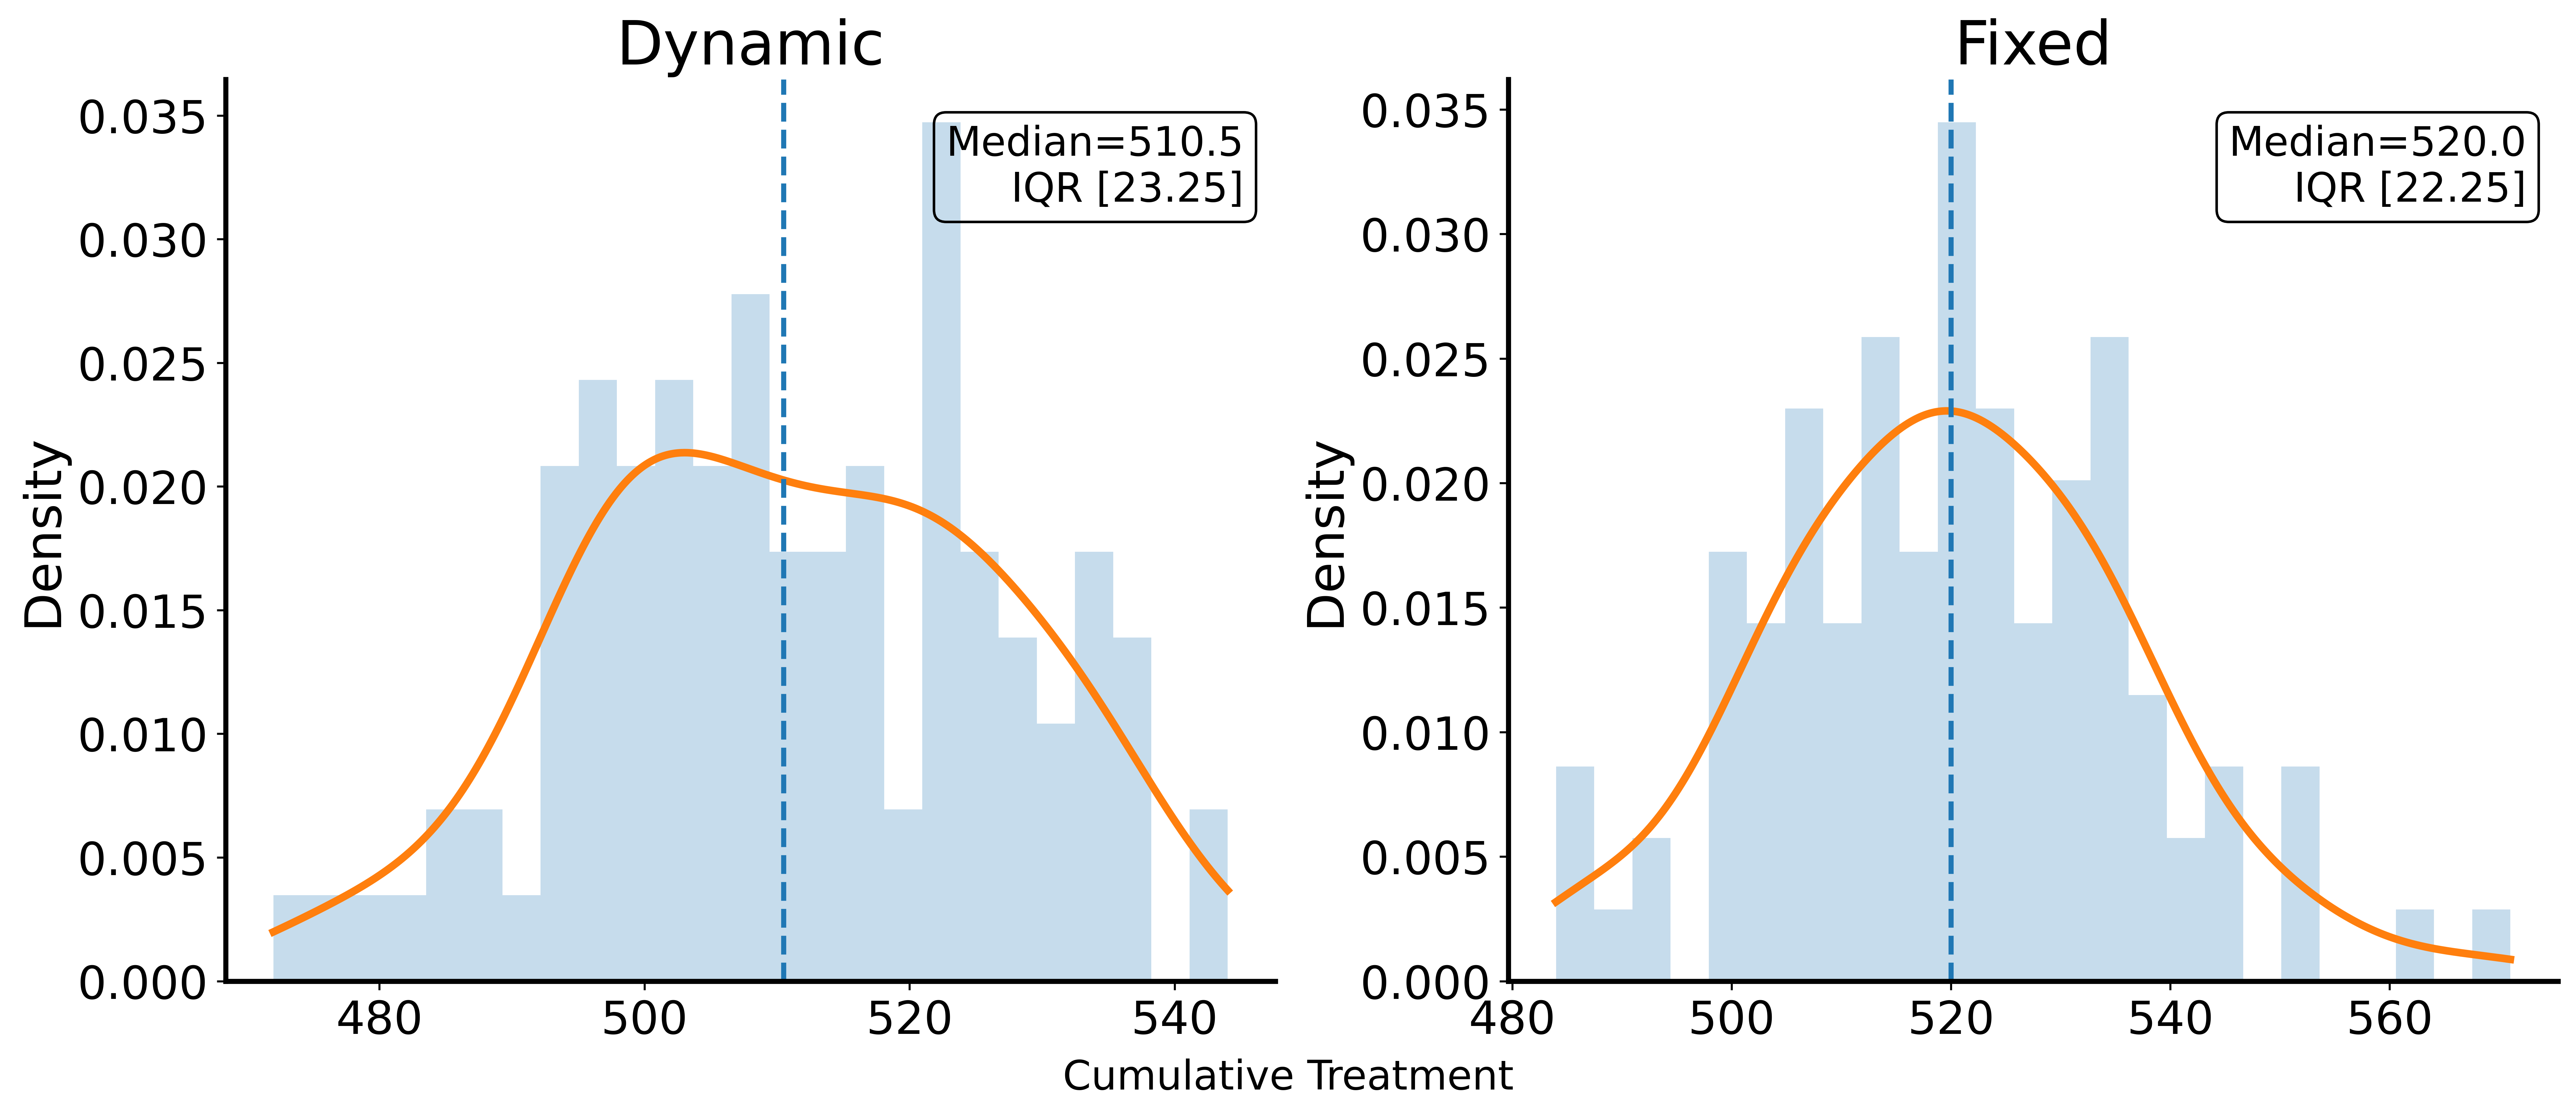

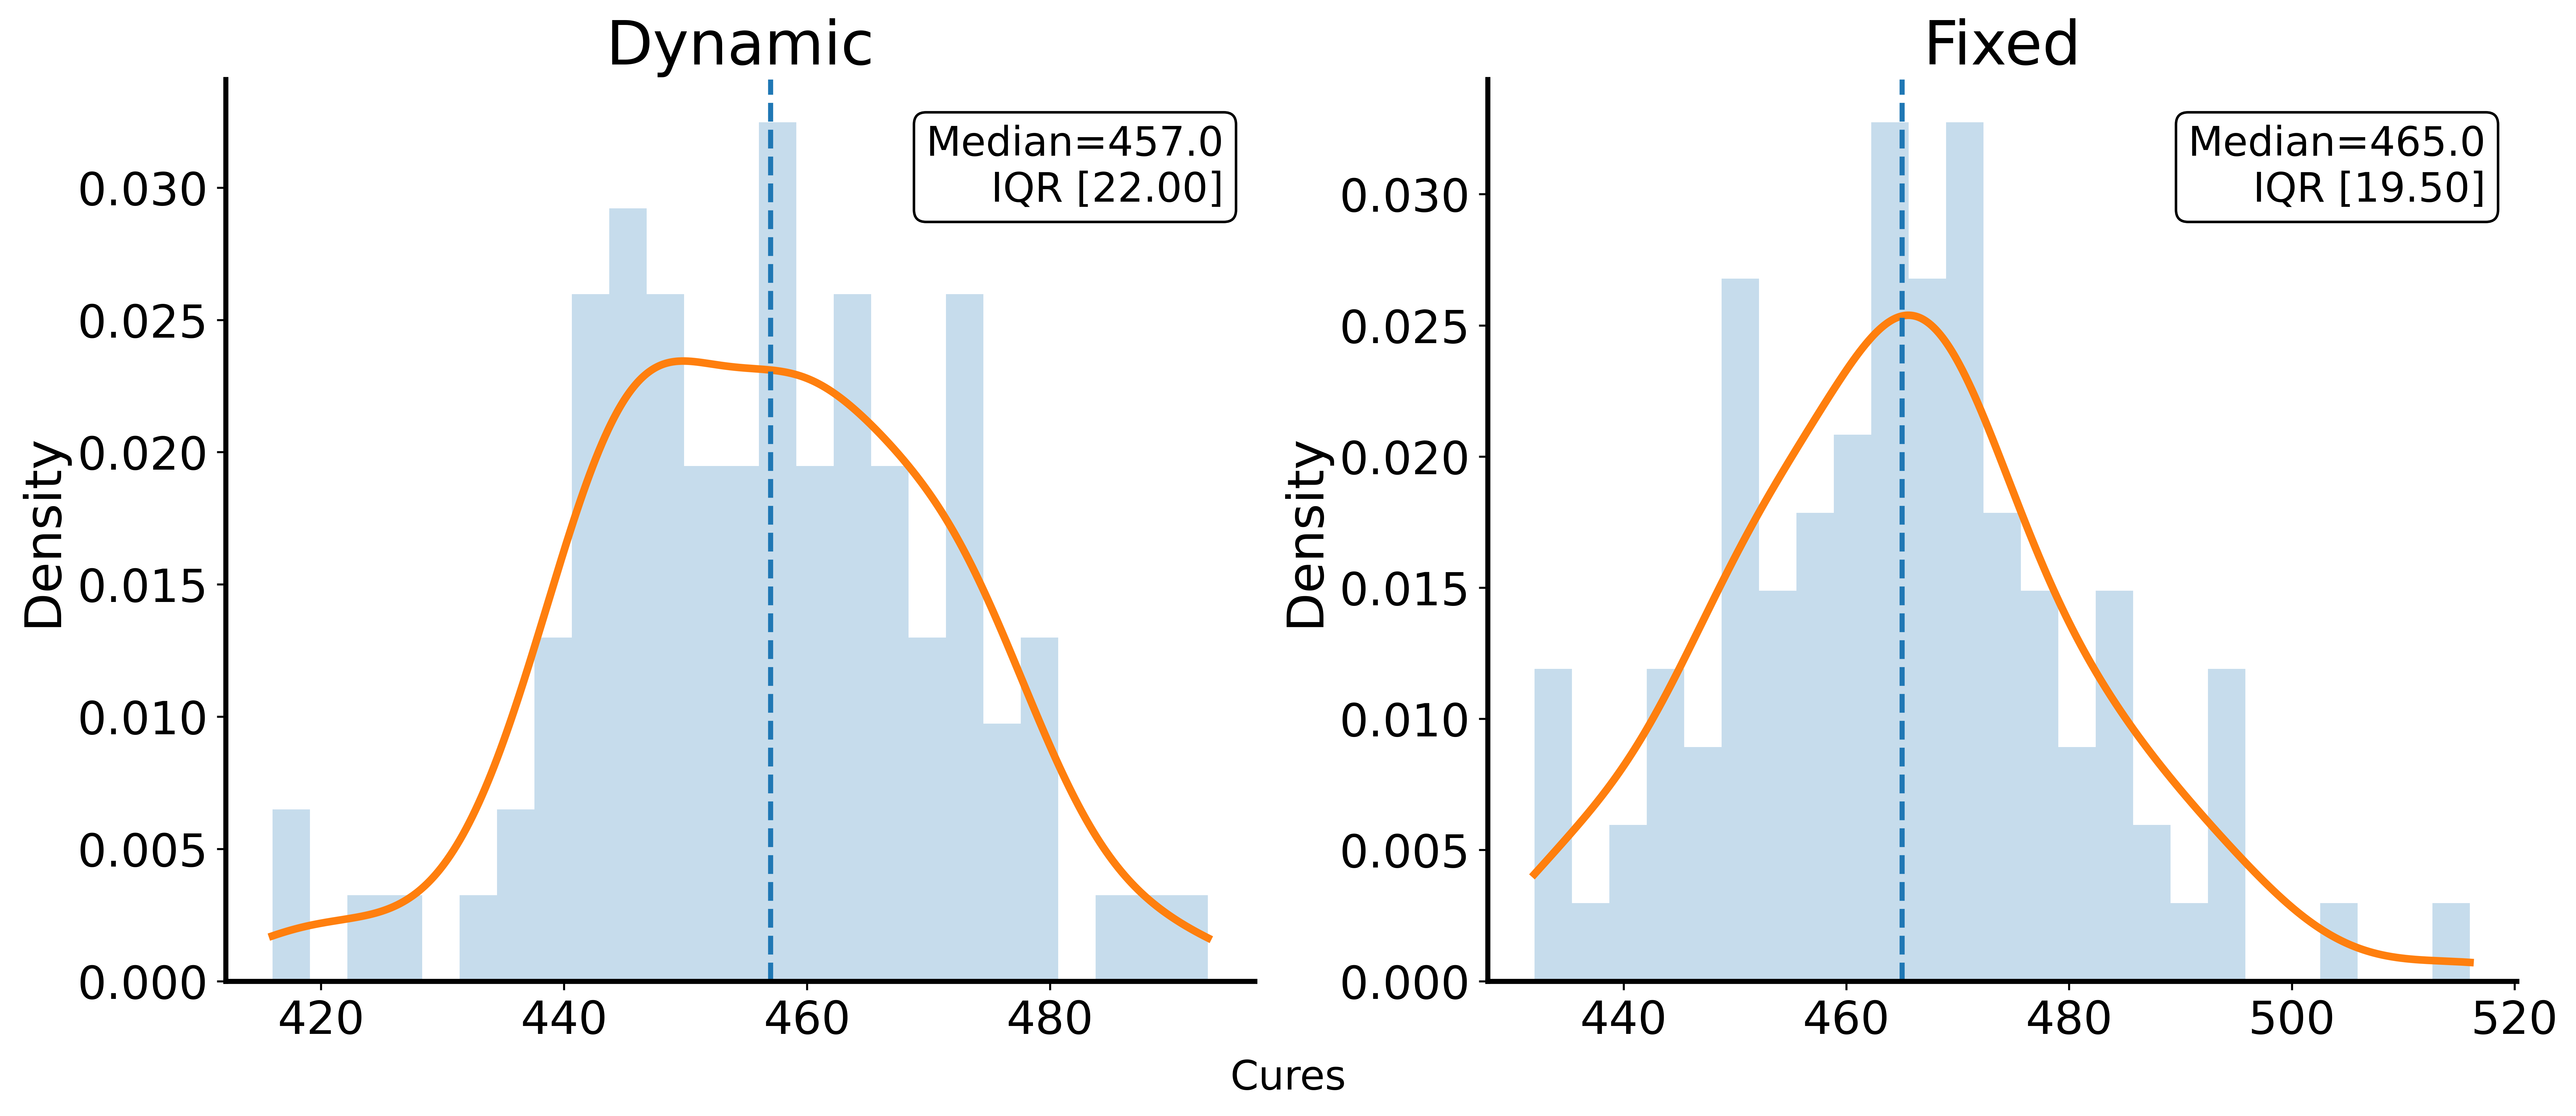

,Outcome,Dynamic median,Dynamic IQR,Fixed median,Fixed IQR,BM,p,P superiority
0,Incidence,6.0,3.00,9.0,3.25,-9.304538,2.727655e-17,0.79430
1,Prevalence,544.0,23.50,555.0,22.25,-5.061730,9.580295e-07,0.68805
2,Cumulative Treatment,510.5,23.25,520.0,22.25,-3.894778,1.344502e-04,0.65035
3,Cures,457.0,22.00,465.0,19.50,-3.772405,2.135183e-04,0.64640


In [8]:
summary=[]

for name,col in OUTCOMES.items():

    dyn=dynamic[
        col
    ].dropna().astype(float)

    fix=fixed[
        col
    ].dropna().astype(float)

    bm,p=brunnermunzel(
        fix,
        dyn
    )

    summary.append({

        "Outcome":name,

        "Dynamic median":
        np.median(dyn),

        "Dynamic IQR":
        iqr(dyn),

        "Fixed median":
        np.median(fix),

        "Fixed IQR":
        iqr(fix),

        "BM":
        bm,

        "p":
        p,

        "P superiority":
        superiority(
            fix,
            dyn
        )

    })

    distribution_plot(
        dyn,
        fix,
        name
    )

summary_df=pd.DataFrame(
    summary
)

summary_df

In [9]:
real=np.array([
698,
601,
552,
538,
511
])

dynamic_matrix=dynamic[
[
"chronic_Y2",
"chronic_Y3",
"chronic_Y4",
"chronic_Y5",
"chronic_Y6"
]
].values

fixed_matrix=fixed[
[
"chronic_Y2",
"chronic_Y3",
"chronic_Y4",
"chronic_Y5",
"chronic_Y6"
]
].values


def mre(
    sim,
    obs
):

    return np.mean(
        np.abs(
            sim-obs
        )/obs
    )

dynamic_mre=np.array([
mre(
x,
real
)
for x in dynamic_matrix
])

fixed_mre=np.array([
mre(
x,
real
)
for x in fixed_matrix
])

bm,p=brunnermunzel(
fixed_mre,
dynamic_mre
)

print(
np.median(
dynamic_mre
),
np.median(
fixed_mre
)
)

print(
bm,
p
)

0.10137120288758267 0.10910200644698242
-4.076873136760512 6.616280065546834e-05


In [10]:
sensitivity=df[
df[
sharing_col
].isin(
[
"low",
"high"
]
)
]

sensitivity.head()

,[run number],sharers-only-size,core-link,initial-infected,num-core,inner-link,outer-link,sharing-rate-sensitivity-level,num-inner,full-population-size,...,Inc_Y4,Inc_Y5,Inc_Y6,Unnamed: 47,Ever_Treat_Y1,Ever_Treat_Y2,Ever_Treat_Y3,Ever_Treat_Y4,Ever_Treat_Y5,Ever_Treat_Y6
0,77,1802,703,985,94,667,432,low,223,16382,...,5,5,5,NaN,128,245,358,426,504,563
1,17,1802,703,985,94,667,432,low,223,16382,...,5,7,8,NaN,143,248,345,426,489,564
2,51,1802,703,985,94,667,432,low,223,16382,...,8,8,8,NaN,144,261,353,436,511,591
3,2,1802,703,985,94,667,432,low,223,16382,...,10,12,6,NaN,131,244,337,423,489,553
4,27,1802,703,985,94,667,432,low,223,16382,...,2,10,7,NaN,114,223,303,392,464,538


In [11]:
# --------------------------------------------------
# SENSITIVITY ANALYSIS: low and high sharing rates
# --------------------------------------------------

sensitivity = df[
    df[sharing_col].isin(["low", "high"])
].copy()

# Make sure grouping column is numeric
sensitivity[group_col] = pd.to_numeric(
    sensitivity[group_col],
    errors="coerce"
)

# Outcomes for sensitivity analysis
SENS_OUTCOMES = {
    "Incidence": "Inc_Y5",
    "Prevalence": "chronic_Y5",
    "Cumulative Treatment": "Ever_Treat_Y5",
    "Cures": "Cured_Y5"
}

# Convert outcome columns to numeric
for col in SENS_OUTCOMES.values():
    sensitivity[col] = pd.to_numeric(
        sensitivity[col],
        errors="coerce"
    )

# --------------------------------------------------
# Run sensitivity analysis
# --------------------------------------------------

sensitivity_rows = []

for scenario in ["low", "high"]:

    temp = sensitivity[
        sensitivity[sharing_col] == scenario
    ]

    dynamic_temp = temp[
        temp[group_col] == 1
    ]

    fixed_temp = temp[
        temp[group_col] == 0
    ]

    print(
        scenario,
        "dynamic runs:",
        len(dynamic_temp),
        "fixed runs:",
        len(fixed_temp)
    )

    for outcome_name, col in SENS_OUTCOMES.items():

        dyn = dynamic_temp[col].dropna().astype(float).values
        fix = fixed_temp[col].dropna().astype(float).values

        bm, p = brunnermunzel(
            fix,
            dyn,
            alternative="two-sided"
        )

        sensitivity_rows.append({
            "Sharing-rate scenario": scenario,
            "Outcome": outcome_name,
            "Dynamic median": np.median(dyn),
            "Dynamic IQR": iqr(dyn),
            "Fixed median": np.median(fix),
            "Fixed IQR": iqr(fix),
            "BM": bm,
            "p": p,
            "P(Fixed > Dynamic)": superiority(fix, dyn)
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

sensitivity_df

low dynamic runs: 100 fixed runs: 100
high dynamic runs: 100 fixed runs: 100


,Sharing-rate scenario,Outcome,Dynamic median,Dynamic IQR,Fixed median,Fixed IQR,BM,p,P(Fixed > Dynamic)
0,low,Incidence,5.0,3.00,8.0,4.00,-8.046123,9.388841e-14,0.76890
1,low,Prevalence,532.5,25.25,545.0,23.00,-6.049444,7.489907e-09,0.71695
2,low,Cumulative Treatment,508.0,24.00,514.0,21.25,-1.836392,6.779995e-02,0.57465
3,low,Cures,455.0,23.25,459.0,22.25,-1.379181,1.693992e-01,0.55630
4,high,Incidence,8.0,4.00,11.0,4.00,-7.796048,3.671756e-13,0.76125
5,high,Prevalence,550.5,23.50,570.0,24.25,-12.404854,1.895019e-26,0.83805
6,high,Cumulative Treatment,512.0,22.25,520.0,24.25,-2.205228,2.864689e-02,0.58960
7,high,Cures,457.5,20.25,465.0,28.00,-2.058962,4.090408e-02,0.58420


In [12]:
# --------------------------------------------------
# Format sensitivity table for manuscript
# --------------------------------------------------

sensitivity_table = sensitivity_df.copy()

sensitivity_table["Dynamic median [IQR]"] = sensitivity_table.apply(
    lambda x: f"{x['Dynamic median']:.1f} [{x['Dynamic IQR']:.2f}]",
    axis=1
)

sensitivity_table["Fixed median [IQR]"] = sensitivity_table.apply(
    lambda x: f"{x['Fixed median']:.1f} [{x['Fixed IQR']:.2f}]",
    axis=1
)

sensitivity_table["BM"] = sensitivity_table["BM"].round(2)

sensitivity_table["p"] = sensitivity_table["p"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

sensitivity_table["P(Fixed > Dynamic)"] = sensitivity_table[
    "P(Fixed > Dynamic)"
].round(3)

sensitivity_table = sensitivity_table[
    [
        "Sharing-rate scenario",
        "Outcome",
        "Dynamic median [IQR]",
        "Fixed median [IQR]",
        "BM",
        "p",
        "P(Fixed > Dynamic)"
    ]
]

sensitivity_table

,Sharing-rate scenario,Outcome,Dynamic median [IQR],Fixed median [IQR],BM,p,P(Fixed > Dynamic)
0,low,Incidence,5.0 [3.00],8.0 [4.00],-8.05,<0.001,0.769
1,low,Prevalence,532.5 [25.25],545.0 [23.00],-6.05,<0.001,0.717
2,low,Cumulative Treatment,508.0 [24.00],514.0 [21.25],-1.84,0.068,0.575
3,low,Cures,455.0 [23.25],459.0 [22.25],-1.38,0.169,0.556
4,high,Incidence,8.0 [4.00],11.0 [4.00],-7.80,<0.001,0.761
5,high,Prevalence,550.5 [23.50],570.0 [24.25],-12.40,<0.001,0.838
6,high,Cumulative Treatment,512.0 [22.25],520.0 [24.25],-2.21,0.029,0.590
7,high,Cures,457.5 [20.25],465.0 [28.00],-2.06,0.041,0.584


In [13]:
sensitivity_table.to_csv(
    OUTPUT_DIR / "sensitivity_analysis_table.csv",
    index=False
)

sensitivity_table.to_excel(
    OUTPUT_DIR / "sensitivity_analysis_table.xlsx",
    index=False
)